In [5]:
import csv
import os

def parse_lat(lat_str):
    """将纬度字符串（如'156N'）转换为浮点数（北正南负）"""
    if not lat_str:
        return None
    lat_str = lat_str.strip()
    num_part = lat_str[:-1]
    direction = lat_str[-1]
    if len(num_part) == 3:
        degrees = int(num_part[0:2])
        minutes = int(num_part[2]) / 10.0
    else:
        # 兼容其他长度
        if len(num_part) == 2:
            degrees = int(num_part[0])
            minutes = int(num_part[1]) / 10.0
        else:
            degrees = int(num_part) // 10
            minutes = (int(num_part) % 10) / 10.0
    lat = degrees + minutes
    if direction == 'S':
        lat = -lat
    return lat

def parse_lon(lon_str):
    """将经度字符串（如'1278E'）转换为浮点数（东正西负）"""
    if not lon_str:
        return None
    lon_str = lon_str.strip()
    num_part = lon_str[:-1]
    direction = lon_str[-1]
    if len(num_part) == 4:
        degrees = int(num_part[0:3])
        minutes = int(num_part[3]) / 10.0
    else:
        if len(num_part) == 3:
            degrees = int(num_part[0:2])
            minutes = int(num_part[2]) / 10.0
        else:
            degrees = int(num_part) // 10
            minutes = (int(num_part) % 10) / 10.0
    lon = degrees + minutes
    if direction == 'W':
        lon = -lon
    return lon

def process_file(filepath, year, typhoon_num, records, seen_times):
    try:
        with open(filepath, 'r', encoding='ascii', errors='ignore') as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                parts = line.split(',')
                if len(parts) < 11:
                    continue
                parts = [p.strip() for p in parts]
                time_str = parts[2]
                if time_str in seen_times:
                    continue
                seen_times.add(time_str)

                lat_str = parts[6]
                lon_str = parts[7]
                wind_str = parts[8]
                pressure_str = parts[9]
                grade = parts[10]

                lat = parse_lat(lat_str)
                lon = parse_lon(lon_str)
                if lat is None or lon is None:
                    continue

                try:
                    wind = int(wind_str) if wind_str else None
                except ValueError:
                    wind = None
                try:
                    pressure = int(pressure_str) if pressure_str else None
                except ValueError:
                    pressure = None

                records.append({
                    'year': year,
                    'typhoon_num': typhoon_num,
                    'time': time_str,
                    'lat': lat,
                    'lon': lon,
                    'wind': wind,
                    'pressure': pressure,
                    'grade': grade
                })
    except FileNotFoundError:
        pass
    except Exception as e:
        print(f"处理文件 {filepath} 时出错: {e}")

def main():
    # ========== 请修改为你的数据存放目录 ==========
    data_dir = r"JTWC Best track"   # 根据你的实际路径修改
    # ===========================================

    # 确保输出目录存在（输出到同一目录）
    output_csv = os.path.join(data_dir, 'typhoon_tracks_2000_2024.csv')
    os.makedirs(os.path.dirname(output_csv), exist_ok=True)

    all_records = []

    for year in range(2000, 2025):
        print(f"处理年份: {year}")
        for num in range(1, 46):
            typhoon_num = f"{num:02d}"
            found = False
            for ext inimport pandas as pd
import cartopy.io.shapereader as shpreader
from shapely.geometry import Point

# 读取台风数据
df = pd.read_excel('JTWC数据及其RI情况1.xlsx', sheet_name='JTWC数据及其RI情况1')

# 加载陆地数据（自然地球）
land_geoms = list(shpreader.Reader(shpreader.natural_earth(resolution='110m', category='physical', name='land')).geometries())

# 判断点是否在陆地
def is_on_land(lon, lat):
    point = Point(lon, lat)
    for geom in land_geoms:
        if geom.contains(point):
            return True
    return False

# 逐行判断（注意：速度较慢，大数据量时可改用空间索引）
df['on_land'] = df.apply(lambda row: is_on_land(row['lon'], row['lat']), axis=1)

# 过滤
ocean_df = df[~df['on_land']]
ocean_df.to_excel('海洋台风路径.xlsx', index=False) ['.txt', '.dat']:
                filename = f"bwp{typhoon_num}{year}{ext}"
                filepath = os.path.join(data_dir, filename)
                if os.path.exists(filepath):
                    seen = set()
                    process_file(filepath, year, typhoon_num, all_records, seen)
                    found = True
                    break
            if not found:
                # 可选：打印未找到的文件（调试用）
                print(f"未找到: {filename}")
                pass

    all_records.sort(key=lambda x: x['time'])

    with open(output_csv, 'w', newline='', encoding='utf-8') as f:
        fieldnames = ['year', 'typhoon_num', 'time', 'lat', 'lon', 'wind', 'pressure', 'grade']
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        for rec in all_records:
            writer.writerow(rec)

    print(f"处理完成，共写入 {len(all_records)} 条记录到 {output_csv}")

if __name__ == '__main__':
    main()

处理年份: 2000
未找到: bwp352000.dat
未找到: bwp362000.dat
未找到: bwp372000.dat
未找到: bwp382000.dat
未找到: bwp392000.dat
未找到: bwp402000.dat
未找到: bwp412000.dat
未找到: bwp422000.dat
未找到: bwp432000.dat
未找到: bwp442000.dat
未找到: bwp452000.dat
处理年份: 2001
未找到: bwp342001.dat
未找到: bwp352001.dat
未找到: bwp362001.dat
未找到: bwp372001.dat
未找到: bwp382001.dat
未找到: bwp392001.dat
未找到: bwp402001.dat
未找到: bwp412001.dat
未找到: bwp422001.dat
未找到: bwp432001.dat
未找到: bwp442001.dat
未找到: bwp452001.dat
处理年份: 2002
未找到: bwp322002.dat
未找到: bwp332002.dat
未找到: bwp342002.dat
未找到: bwp352002.dat
未找到: bwp362002.dat
未找到: bwp372002.dat
未找到: bwp382002.dat
未找到: bwp392002.dat
未找到: bwp402002.dat
未找到: bwp412002.dat
未找到: bwp422002.dat
未找到: bwp432002.dat
未找到: bwp442002.dat
未找到: bwp452002.dat
处理年份: 2003
未找到: bwp282003.dat
未找到: bwp292003.dat
未找到: bwp302003.dat
未找到: bwp312003.dat
未找到: bwp322003.dat
未找到: bwp332003.dat
未找到: bwp342003.dat
未找到: bwp352003.dat
未找到: bwp362003.dat
未找到: bwp372003.dat
未找到: bwp382003.dat
未找到: bwp392003.dat
未找到: bwp402003.dat
未找到: b

In [20]:
import pandas as pd
import numpy as np

# 读取数据
df = pd.read_csv("typhoon_tracks_2000_2024.csv")

# 时间处理
df['datetime'] = pd.to_datetime(df['time'].astype(str), format='%Y%m%d%H', errors='coerce')
df = df.dropna(subset=['datetime']).reset_index(drop=True)

# 按台风编号和时间排序
df = df.sort_values(['typhoon_num', 'datetime']).reset_index(drop=True)

# 初始化标记列
df['intensity_change_flag'] = 0

# 分组处理
for typhoon_num, group in df.groupby('typhoon_num'):
    group = group.sort_values('datetime')
    orig_indices = group.index          # 原始DataFrame中的行号
    times = group['datetime'].values
    winds = group['wind'].values
    n = len(group)
    
    for i in range(n):
        curr_time = times[i]
        curr_wind = winds[i]
        # 未来24小时内的记录（不包括当前时刻本身）
        future_mask = (times > curr_time) & (times <= curr_time + pd.Timedelta(hours=24))
        future_indices = np.where(future_mask)[0]
        if len(future_indices) == 0:
            # 没有未来数据（台风即将消散）
            df.loc[orig_indices[i], 'intensity_change_flag'] = 0
            continue
        
        future_winds = winds[future_indices]
        max_future = future_winds.max()
        min_future = future_winds.min()
        last_future_wind = future_winds[-1]
        if max_future >= curr_wind + 30 or max_future >= min_future + 30 and last_future_wind>=curr_wind:
            flag = 1      # 未来24h内将出现≥30kt的净增强（RI）
        elif max_future > curr_wind:
            flag = 2      # 未来有增强，但净增强不足30kt
        else:
            flag = 3      # 未来一直减弱或强度不变
        df.loc[orig_indices[i], 'intensity_change_flag'] = flag

# 删除辅助列
df = df.drop(columns=['datetime'])

# 保存结果
df.to_csv("typhoon_tracks_2000_2024_flagged.csv", index=False)

print("处理完成，所有行已标记。")

处理完成，所有行已标记。


In [18]:
import pandas as pd

# 1. 读取原始台风路径数据
orig_df = pd.read_csv("typhoon_tracks_2000_2024.csv")
orig_df['datetime'] = pd.to_datetime(orig_df['time'].astype(str), format='%Y%m%d%H', errors='coerce')
orig_df['year'] = orig_df['datetime'].dt.year               # 保留年份
orig_df['hour_str'] = orig_df['datetime'].dt.strftime('%Y-%m-%d %H:00:00')

# 2. 读取 DeepTCSize 数据（文件名已指定）
deep_df = pd.read_csv("DeepTCSize_2023v1 (1).csv")
deep_df['datetime'] = pd.to_datetime(deep_df['ISO_TIME'], errors='coerce')
deep_df['hour_str'] = deep_df['datetime'].dt.strftime('%Y-%m-%d %H:00:00')
deep_df['year'] = deep_df['datetime'].dt.year

# 从 USA_ATCF_ID 提取台风编号和年份（格式如 WP011981 → 编号1, 年份1981）
def parse_atcf(atcf):
    if pd.isna(atcf) or not isinstance(atcf, str) or len(atcf) < 8:
        return None, None
    try:
        num = int(atcf[2:4])      # 两位数编号，例如 01 -> 1
        year = int(atcf[4:8])
        return num, year
    except:
        return None, None

deep_df[['typhoon_num', 'atcf_year']] = deep_df['USA_ATCF_ID'].apply(
    lambda x: pd.Series(parse_atcf(x))
)

# 只保留 2000-2017 年的数据（因为原始数据包含 2024，但 DeepTCSize 只到 2017）
deep_df = deep_df[(deep_df['atcf_year'] >= 2000) & (deep_df['atcf_year'] <= 2017)]

# 3. 构造匹配键（年份 + 台风编号 + 小时字符串）
orig_df['match_key'] = orig_df['year'].astype(str) + '_' + orig_df['typhoon_num'].astype(str) + '_' + orig_df['hour_str']
deep_df['match_key'] = deep_df['atcf_year'].astype(str) + '_' + deep_df['typhoon_num'].astype(str) + '_' + deep_df['hour_str']

# 4. 提取需要添加的两列
deep_sub = deep_df[['match_key', 'DeepTCSize_R34', 'DeepTCSize_RMW']].drop_duplicates(subset='match_key')

# 5. 左连接，保留原始数据全部行
merged = orig_df.merge(deep_sub, on='match_key', how='left')

# 6. 清理临时列
merged = merged.drop(columns=['datetime', 'hour_str', 'match_key'])

# 7. 将新列放到末尾
cols = [c for c in merged.columns if c not in ['DeepTCSize_R34', 'DeepTCSize_RMW']]
cols += ['DeepTCSize_R34', 'DeepTCSize_RMW']
merged = merged[cols]

# 8. 保存结果
merged.to_csv("typhoon_tracks_with_deep.csv", index=False)

print("配对完成！结果已保存为 typhoon_tracks_with_deep.csv")

配对完成！结果已保存为 typhoon_tracks_with_deep.csv


数据处理完成！


In [4]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point

# 1. 读取台风数据
df = pd.read_excel('副本JTWC数据及其RI情况1.xlsx', sheet_name='JTWC数据及其RI情况1')

# 2. 加载全球陆地数据（无废弃API）
land = gpd.read_file(
    "https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_110m_land.geojson"
)
# ✅ 修复警告：替换为 union_all()
land_union = land.geometry.union_all()

# 3. 转换为空间数据
geometry = [Point(lon, lat) for lat, lon in zip(df['lat'], df['lon'])]
gdf = gpd.GeoDataFrame(df, geometry=geometry, crs="EPSG:4326")

# 4. 判断是否在陆地
gdf['on_land'] = gdf.geometry.within(land_union)

# 5. 筛选海洋上的台风点
ocean_typhoon = gdf[~gdf['on_land']]

# 6. 保存结果
ocean_typhoon.drop(columns="geometry").to_excel('海洋台风路径.xlsx', index=False, engine="openpyxl")

print(f"原始数据：{len(df)} 个点")
print(f"海洋台风点：{len(ocean_typhoon)} 个点")
print("文件已保存：海洋台风路径.xlsx")

原始数据：19830 个点
海洋台风点：18497 个点
文件已保存：海洋台风路径.xlsx


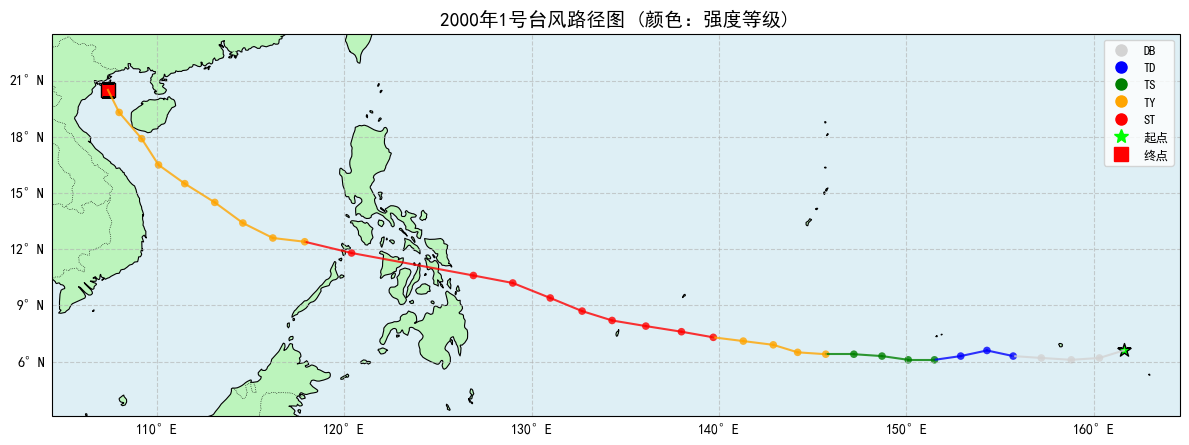

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.lines as mlines

# ================== 中文显示设置 ==================
plt.rcParams['font.sans-serif'] = ['SimHei']        # 用黑体显示中文
plt.rcParams['axes.unicode_minus'] = False          # 解决负号显示问题

# ================== 数据读取 ==================
df = pd.read_excel('海洋台风路径.xlsx')

# 筛选 2000 年 1 号台风
typhoon = df[(df['year'] == 2013) & (df['typhoon_num'] == 31)].copy()
typhoon = typhoon.sort_values('time')               # 按时间排序

# ================== 强度颜色映射 ==================
grade_color = {
    'DB': 'lightgray',
    'TD': 'blue',
    'TS': 'green',
    'TY': 'orange',
    'ST': 'red',
    'ET': 'purple',
    'EX': 'magenta'
}

# ================== 创建地图 ==================
# 使用 PlateCarree 投影（等经纬度）
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

# 添加地理要素
ax.add_feature(cfeature.LAND, facecolor='lightgreen', alpha=0.6)      # 陆地
ax.add_feature(cfeature.OCEAN, facecolor='lightblue', alpha=0.4)      # 海洋
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)                     # 海岸线
ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)        # 国界线（可选）
ax.add_feature(cfeature.LAKES, facecolor='lightblue', alpha=0.3)      # 湖泊

# 设置地图范围（根据台风路径自动扩展）
margin = 3
lon_min, lon_max = typhoon['lon'].min() - margin, typhoon['lon'].max() + margin
lat_min, lat_max = typhoon['lat'].min() - margin, typhoon['lat'].max() + margin
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

# 添加网格线（经纬度）
gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.6)
gl.top_labels = False
gl.right_labels = False

# ================== 绘制台风路径 ==================
# 按顺序画线段，颜色根据起点强度
for i in range(len(typhoon) - 1):
    lon0, lat0 = typhoon.iloc[i]['lon'], typhoon.iloc[i]['lat']
    lon1, lat1 = typhoon.iloc[i+1]['lon'], typhoon.iloc[i+1]['lat']
    grade = typhoon.iloc[i]['grade']
    color = grade_color.get(grade, 'black')
    ax.plot([lon0, lon1], [lat0, lat1], color=color, linewidth=1.5,
            alpha=0.8, transform=ccrs.PlateCarree())

# 绘制每个点（按强度着色）
for _, row in typhoon.iterrows():
    ax.scatter(row['lon'], row['lat'], color=grade_color.get(row['grade'], 'black'),
               s=30, edgecolors='none', alpha=0.8, transform=ccrs.PlateCarree())

# 起点和终点标记
start = typhoon.iloc[0]
end = typhoon.iloc[-1]
ax.scatter(start['lon'], start['lat'], color='lime', s=100, marker='*',
           edgecolors='black', label=f'起点 ({start["time"]})', transform=ccrs.PlateCarree())
ax.scatter(end['lon'], end['lat'], color='red', s=100, marker='s',
           edgecolors='black', label=f'终点 ({end["time"]})', transform=ccrs.PlateCarree())

# ================== 图例 ==================
handles = []
for grade, color in grade_color.items():
    if grade in typhoon['grade'].unique():
        handles.append(mlines.Line2D([], [], color=color, marker='o',
                                     linestyle='None', markersize=8, label=grade))
handles += [
    plt.Line2D([0], [0], marker='*', color='lime', linestyle='None', markersize=10, label='起点'),
    plt.Line2D([0], [0], marker='s', color='red', linestyle='None', markersize=10, label='终点')
]
ax.legend(handles=handles, loc='upper right', fontsize=9)

# ================== 标题和输出 ==================
ax.set_title('2000年1号台风路径图 (颜色：强度等级)', fontsize=14)
plt.tight_layout()
plt.savefig('typhoon_2000_01_map.png', dpi=150, bbox_inches='tight')
plt.show()

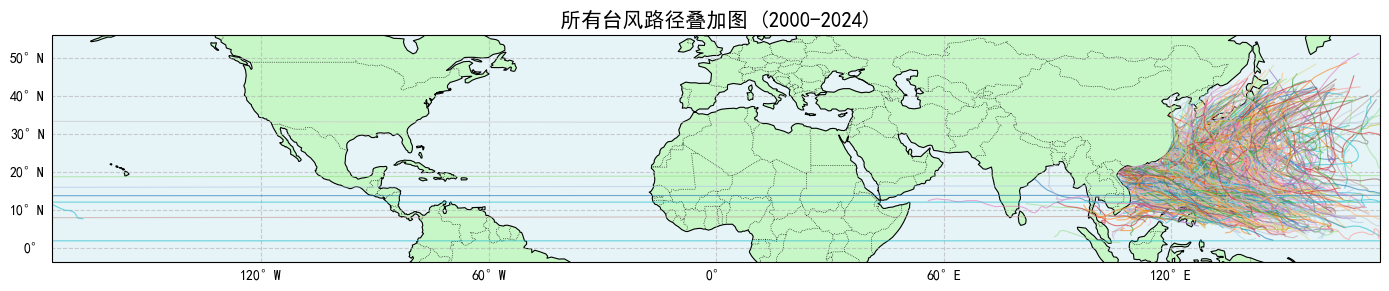

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_excel('海洋台风路径.xlsx')

# 创建地图
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

# 地理要素
ax.add_feature(cfeature.LAND, facecolor='lightgreen', alpha=0.5)
ax.add_feature(cfeature.OCEAN, facecolor='lightblue', alpha=0.3)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)

# 设置整体范围（可手动调整，这里用数据整体范围加边距）
margin = 5
lon_min, lon_max = df['lon'].min() - margin, df['lon'].max() + margin
lat_min, lat_max = df['lat'].min() - margin, df['lat'].max() + margin
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

# 网格线
gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.6)
gl.top_labels = False
gl.right_labels = False

# 按台风分组绘制（每条台风一种颜色，使用颜色循环）
colors = plt.cm.tab20.colors  # 可选 colormap
color_idx = 0

for (year, num), group in df.groupby(['year', 'typhoon_num']):
    group = group.sort_values('time')
    if len(group) < 2:
        continue
    # 取一种颜色（循环）
    color = colors[color_idx % len(colors)]
    color_idx += 1

    # 绘制连线
    lons = group['lon'].values
    lats = group['lat'].values
    ax.plot(lons, lats, color=color, linewidth=0.8, alpha=0.6,
            transform=ccrs.PlateCarree(), label=f'{year}年{num}号')

# 图例太多会重叠，这里不显示图例；若需图例可去掉下面一行的注释，但建议只显示部分
# ax.legend(loc='upper right', fontsize=6, ncol=2)

ax.set_title('所有台风路径叠加图 (2000-2024)', fontsize=15)
plt.tight_layout()
plt.savefig('all_typhoons_overlay.png', dpi=200, bbox_inches='tight')
plt.show()